# Preprocessing


In [ ]:
import pandas as pd
import pickle
import numpy as np
import torch


df = pd.read_hdf("metr-la.h5")

# make sure the index is datetime
df.index = pd.to_datetime(df.index)

print("Raw df shape:", df.shape)   # expected: (34272, 207)


with open("adj_mx.pkl", "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding="latin1")

print("Adjacency shape:", adj_mx.shape)   # expected: (207, 207)



np.fill_diagonal(adj_mx, 0)
adj_mx = (adj_mx != 0).astype(np.float32)
#adj_mx = np.maximum(adj_mx, adj_mx.T)


df_daily = df.between_time("09:00", "15:00").resample("1D").mean()  # std()
Y_daily = df_daily.to_numpy().T

print("Y_daily shape:", Y_daily.shape)   # expected: (207, 119)


Y_mean = Y_daily.mean(axis=1, keepdims=True)
Y_std = Y_daily.std(axis=1, keepdims=True) + 1e-8
Y_daily_std = (Y_daily - Y_mean) / Y_std



Y_tensor = torch.tensor(Y_daily_std, dtype=torch.float32)
adj_tensor = torch.tensor(adj_mx, dtype=torch.float32)

print("Y_tensor shape:", Y_tensor.shape)
print("adj_tensor shape:", adj_tensor.shape)


torch.save(
    {
        "Y": Y_tensor,
        "adj": adj_tensor,
    },
    "metr_la_daily_standardized.pt"
)

print("Saved to metr_la_daily_standardized.pt")

# Plot

In [9]:
import sys
!{sys.executable} -m pip install geopandas contextily

In [1]:
cluster_file = "../../result/traffic_20261006_195817/clusters_pen2.txt"

with open(cluster_file, "r") as f:
    detected_cluster = [
        [int(x) for x in line.split()]
        for line in f
        if line.strip()
    ]

In [2]:

import numpy as np

num_nodes = 207
labels = -1 * np.ones(num_nodes, dtype=int)

for cluster_id, cluster in enumerate(detected_cluster):
    for node in cluster:
        labels[node] = cluster_id


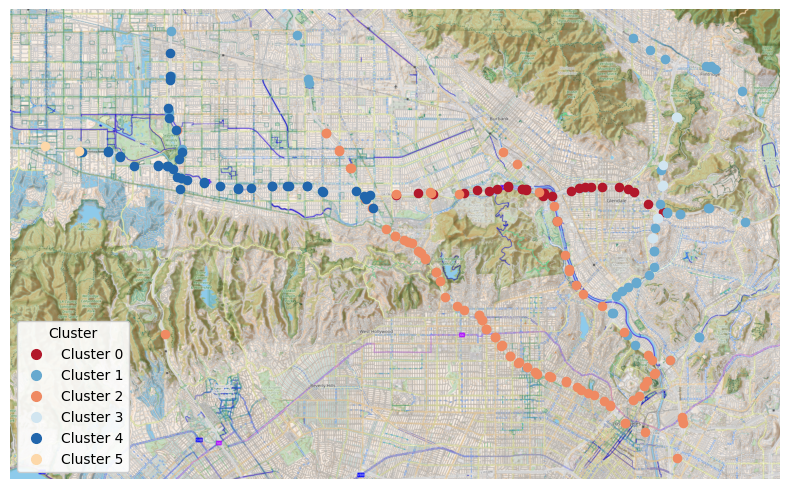

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from matplotlib.lines import Line2D

# Settings
FIGSIZE = (8, 6)
DPI = 200

# Sensor locations
sensor_df = pd.read_csv("graph_sensor_locations.csv")
coords = sensor_df[["latitude", "longitude"]].values

# GeoDataFrame
gdf = gpd.GeoDataFrame(
    {"cluster": labels.astype(int)},
    geometry=gpd.points_from_xy(coords[:, 1], coords[:, 0]),
    crs="EPSG:4326"
).to_crs(3857)


clusters = sorted(gdf["cluster"].unique())
colors = [
    '#B2182B',  # Dark red
    '#67A9CF',  # Medium blue
    '#EF8A62',  # Coral
    '#D1E5F0',  # Light blue
    '#2166AC',  # Dark blue
    '#FDD8A9',  # Light peach
]
color_map = dict(zip(clusters, colors))

# Plot
fig, ax = plt.subplots(figsize=FIGSIZE)

for cluster in clusters:
    gdf[gdf["cluster"] == cluster].plot(
        ax=ax,
        color=color_map[cluster],
        markersize=35,
        label=f"Cluster {cluster}",
        zorder=2
    )

# OSM-style basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CyclOSM,
    zoom=13,
    attribution=False,
    zorder=1
)

# Legend
handles = [
    Line2D(
        [], [], marker="o", linestyle="",
        color=color_map[c],
        markerfacecolor=color_map[c],
        markersize=7,
        label=f"Cluster {c}"
    )
    for c in clusters
]

ax.legend(
    handles=handles,
    title="Cluster",
    loc="lower left",
    frameon=True,
    framealpha=0.9
)

ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    "LA_traffic.pdf",
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()